# **Heart Disease Prediction**

## Import Libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

## DataSet Load:

In [ ]:
df = pd.read_csv("/content/framingham.csv")

In [ ]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


## EDA:

In [ ]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [ ]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4235,False
4236,False
4237,False
4238,False


In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


## Fill Missing Values:

In [ ]:
df.dropna(axis = 0, inplace = True)

In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [ ]:
df = df.drop(['education','heartRate','BPMeds'], axis=1)

In [ ]:
print(df.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


# Data Visualization:

## HeatMap:

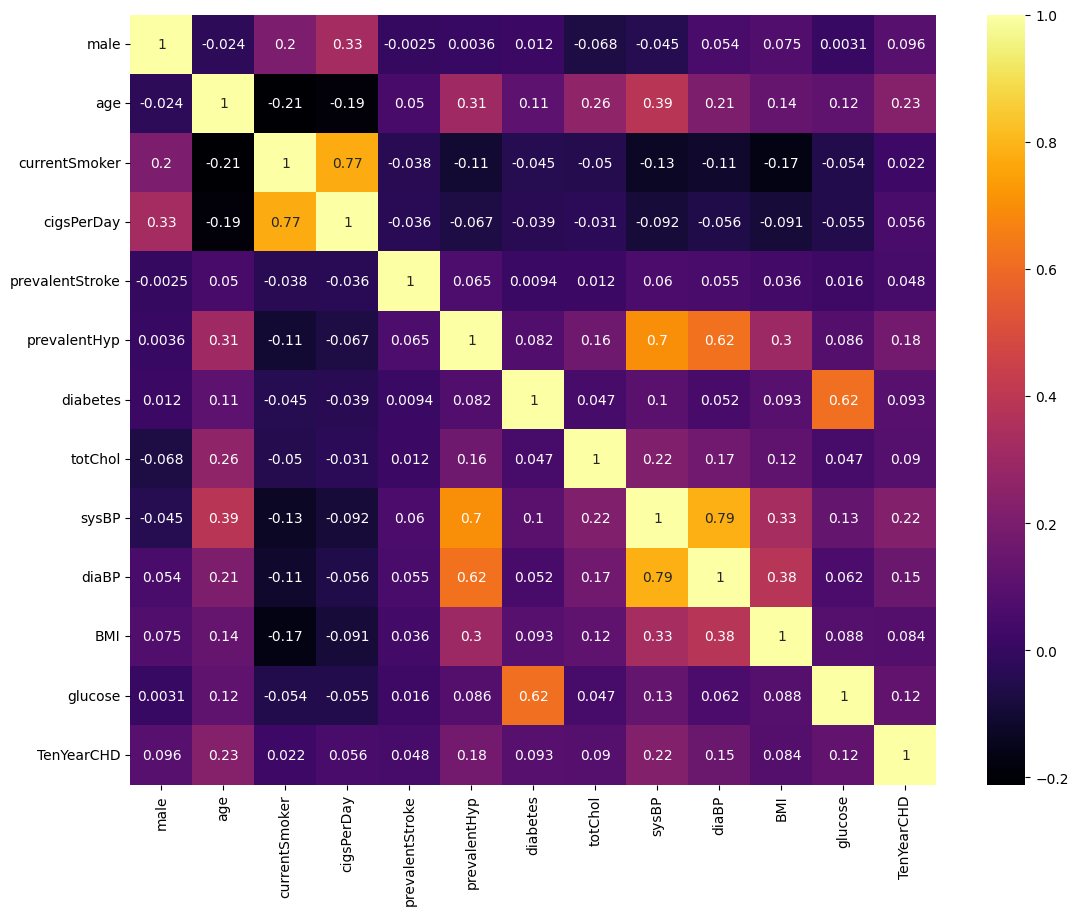

In [ ]:
plt.figure(figsize=(13,10))
sns.heatmap(df.corr(), annot=True, cmap="inferno")
plt.show()

## Countplot:

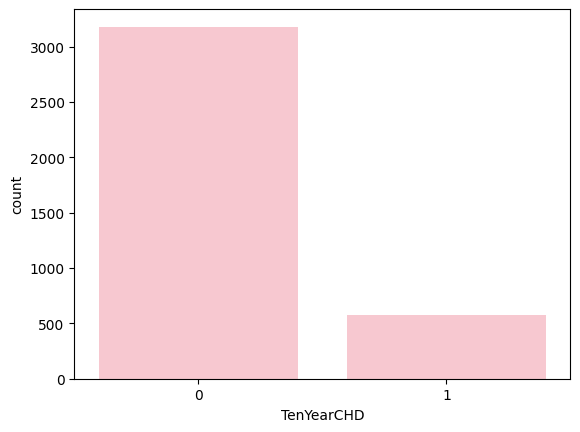

In [ ]:
sns.countplot(x='TenYearCHD', data=df, color='pink')
plt.show()

## Dividing Data Into X & Y:

In [ ]:
x = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

In [ ]:
x

,male,age,currentSmoker,cigsPerDay,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,glucose
0,1,39,0,0.0,0,0,0,195.0,106.0,70.0,26.97,77.0
1,0,46,0,0.0,0,0,0,250.0,121.0,81.0,28.73,76.0
2,1,48,1,20.0,0,0,0,245.0,127.5,80.0,25.34,70.0
3,0,61,1,30.0,0,1,0,225.0,150.0,95.0,28.58,103.0
4,0,46,1,23.0,0,0,0,285.0,130.0,84.0,23.10,85.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0,1,0,313.0,179.0,92.0,25.97,86.0
4234,1,51,1,43.0,0,0,0,207.0,126.5,80.0,19.71,68.0
4237,0,52,0,0.0,0,0,0,269.0,133.5,83.0,21.47,107.0
4238,1,40,0,0.0,0,1,0,185.0,141.0,98.0,25.60,72.0


In [ ]:
y

,TenYearCHD
0,0
1,0
2,0
3,1
4,0
...,...
4233,1
4234,0
4237,0
4238,0


## Split The Data Into Training & Testing:

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

## Scaling The Data:

In [ ]:
scaler = StandardScaler()

x_scaled_train = scaler.fit_transform(x_train)
x_scaled_test = scaler.transform(x_test)

## Model Training:

In [ ]:
logreg = LogisticRegression()
logreg.fit(x_scaled_train, y_train)

pred_logreg = logreg.predict(x_scaled_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_scaled_train, y_train)

pred_knn = knn.predict(x_scaled_test)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_scaled_train, y_train)

pred_dt = dt.predict(x_scaled_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_scaled_train, y_train)

pred_rf = rf.predict(x_scaled_test)

In [ ]:
svm = SVC()
svm.fit(x_scaled_train, y_train)

pred_svm = svm.predict(x_scaled_test)

## Accuracy Check:

In [ ]:
accuracy = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_logreg),
        accuracy_score(y_test,pred_knn),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_svm)
    ]
})

print(accuracy)

                 Model  Accuracy
0  Logistic Regression  0.834813
1                  KNN  0.818828
2        Decision Tree  0.738899
3        Random Forest  0.828597
4                  SVM  0.828597


## Classification Report:

In [ ]:
print(classification_report(y_test, pred_logreg))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.54      0.07      0.12       188

    accuracy                           0.83      1126
   macro avg       0.69      0.53      0.52      1126
weighted avg       0.79      0.83      0.78      1126



## Confusion Matrix:

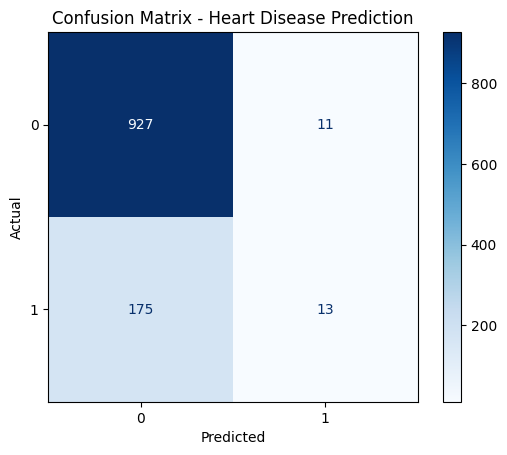

In [ ]:
cm = ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logreg,
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heart Disease Prediction")
plt.show()

## Prediction for New Patient:

In [ ]:
new_data = pd.DataFrame([[1,60,1,20,0,1,1,300,170,100,32,180]],
                        columns=x_train.columns)

In [ ]:
new_data_scaled = scaler.transform(new_data)

In [ ]:
prediction = logreg.predict(new_data_scaled)

In [ ]:
prediction = logreg.predict(new_data_scaled)

if prediction[0] == 1:
    print("Heart Disease Risk")
else:
    print("No Heart Disease")

Heart Disease Risk


In [ ]:
prob = logreg.predict_proba(new_data_scaled)

print("No Heart Disease Probability:", prob[0][0])
print()
print("Heart Disease Probability:", prob[0][1])

No Heart Disease Probability: 0.33747423261560283

Heart Disease Probability: 0.6625257673843972


In [ ]:
import joblib
joblib.dump(logreg, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [ ]:
from google.colab import files
files.download("heart_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Scaling file -> pkl
joblib.dump(scaler,"scale.pkl")
files.download("scale.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>